# Notebook 10a: 18-Class Re-Evaluation of Phase 3b Model
============================================================
**Purpose:** Properly evaluate the Phase 3b sequential model on 18 viable classes
(excluding Trifolium Repens and Ziziphus mauritiana) to produce:
- Exact 18-class accuracy, precision, recall, F1
- Proper classification_report on 18 classes
- 18-class confusion matrix
- Fair comparison numbers for ablation (direct 74.46% vs sequential on same 18 classes)

**Student:** Hari (3146279) | BSc Software Engineering | University of Stirling

**Run in Google Colab with GPU runtime.**

**v2 fix:** Uses shuffle=True (default) for data split to match NB05/NB08 split.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU!")

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: /physical_device:GPU:0


In [2]:
# ── Configuration ──
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "18class_eval_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

DROP_CLASSES = ['Trifolium Repens', 'Trifolium_Repens',
                'Ziziphus mauritiana', 'Ziziphus_mauritiana']

print(f"Project dir: {PROJECT_DIR}")
print(f"Results dir: {RESULTS_DIR}")

Project dir: /content/drive/MyDrive/MedicinalPlant_Dissertation
Results dir: /content/drive/MyDrive/MedicinalPlant_Dissertation/18class_eval_results


## 1. Find and Load Dataset 5 (18 classes only)

In [3]:
def find_image_directory(base_dir):
    """Walk directory tree to find folder containing class subdirectories with images."""
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in sample_files)
            if has_images:
                return root
    return None

# Find Dataset 5
print(">>> Finding Dataset 5 (SIMPD)...")
dataset5_path = None
for p in [os.path.join(DATA_DIR, "dataset5"),
          os.path.join(DATA_DIR, "Dataset 5"),
          os.path.join(DATA_DIR, "SIMPD")]:
    if os.path.exists(p):
        found = find_image_directory(p)
        if found:
            dataset5_path = found
            break

if dataset5_path is None:
    raise FileNotFoundError("Dataset 5 not found!")
print(f"Dataset 5 found: {dataset5_path}")

# Get all 20 classes (needed for model output mapping)
all_classes = sorted([
    d for d in os.listdir(dataset5_path)
    if os.path.isdir(os.path.join(dataset5_path, d)) and not d.startswith('.')
])
print(f"All classes (20): {all_classes}")

# Create filtered 18-class copy
keep_classes = [c for c in all_classes if c not in DROP_CLASSES]
print(f"\nKeeping {len(keep_classes)} classes (dropping {DROP_CLASSES})")

filtered_d5 = "/content/eval_dataset5_18class"
if os.path.exists(filtered_d5):
    shutil.rmtree(filtered_d5)
os.makedirs(filtered_d5)
for c in keep_classes:
    shutil.copytree(os.path.join(dataset5_path, c), os.path.join(filtered_d5, c))

# Load validation set — MUST use shuffle=True (default) to match NB05/NB08 split!
# shuffle=False would take the last 20% of files alphabetically, giving only ~5 classes.
# The seed=42 ensures the same reproducible split as the original notebooks.
val_ds = tf.keras.utils.image_dataset_from_directory(
    filtered_d5, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, label_mode='int', validation_split=0.2, subset='validation'
)

class_names_18 = sorted(os.listdir(filtered_d5))
NUM_CLASSES_18 = len(class_names_18)
print(f"\n18-class validation set loaded")
print(f"Classes: {class_names_18}")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

# Verify all 18 classes are represented
label_counts = {}
for _, labels in val_ds:
    for l in labels.numpy():
        label_counts[int(l)] = label_counts.get(int(l), 0) + 1
print(f"Unique classes in val set: {len(label_counts)} (should be 18)")
assert len(label_counts) >= 17, f"ERROR: Only {len(label_counts)} classes in val set! Split is wrong."
for idx in sorted(label_counts.keys()):
    print(f"  {class_names_18[idx]}: {label_counts[idx]} samples")

# Normalise
norm = layers.Rescaling(1./255)
val_ds_norm = val_ds.map(lambda x, y: (norm(x), y)).prefetch(tf.data.AUTOTUNE)

>>> Finding Dataset 5 (SIMPD)...
Dataset 5 found: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset5/SIMPD V1 South Indian Medicinal Plants dataset (Version 1)
All classes (20): ['Abutilon Indicum', 'Aloe barbadensis miller', 'Calotropis gigantea', 'Canna indica', 'Cissus quadrangularis', 'Curcuma longa', 'Eclipta prostrate', 'Eichhornia Crassipes', 'Hibiscus Rosasinensis', 'Ixora coccinea', 'Justica adhatoda', 'Murraya koenigii', 'Ocimum tenuiflorum', 'Ouretlanata', 'Phyllanthus amarus', 'Ricinus communis', 'Senna Atriculata', 'Sesbania grandiflora', 'Trifolium Repens', 'Ziziphus mauritiana']

Keeping 18 classes (dropping ['Trifolium Repens', 'Trifolium_Repens', 'Ziziphus mauritiana', 'Ziziphus_mauritiana'])
Found 2313 files belonging to 18 classes.
Using 462 files for validation.

18-class validation set loaded
Classes: ['Abutilon Indicum', 'Aloe barbadensis miller', 'Calotropis gigantea', 'Canna indica', 'Cissus quadrangularis', 'Curcuma longa', 'Eclipta prostrate', 'E

## 2. Load Phase 3b Model (20-class)

In [4]:
PHASE3B_MODEL_PATH = os.path.join(MODEL_DIR, "phase3b_commercial.keras")
print(f"Loading Phase 3b model: {PHASE3B_MODEL_PATH}")

model = None

# Attempt 1: direct load
for kw in [dict(), dict(compile=False), dict(compile=False, safe_mode=False)]:
    try:
        model = keras.models.load_model(PHASE3B_MODEL_PATH, **kw)
        print(f"  Loaded with load_model({kw})")
        break
    except Exception as e:
        print(f"  load_model failed ({kw}): {e}")

# Attempt 2: rebuild from .keras ZIP
if model is None and PHASE3B_MODEL_PATH.endswith('.keras'):
    print("\n  Attempting rebuild + weight extraction from .keras archive...")
    weights_tmp = os.path.join(MODEL_DIR, '_temp_phase3b.weights.h5')
    try:
        with zipfile.ZipFile(PHASE3B_MODEL_PATH, 'r') as zf:
            with zf.open('model.weights.h5') as src, open(weights_tmp, 'wb') as dst:
                dst.write(src.read())

        keras.backend.clear_session()
        _base = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
        _aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
        ], name="augmentation_commercial")

        model = keras.Sequential([
            keras.Input(shape=(224, 224, 3)),
            _aug,
            _base,
            layers.GlobalAveragePooling2D(),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(20, activation='softmax'),
        ], name="phase3b_commercial")

        model.load_weights(weights_tmp)
        print(f"  Rebuilt architecture + loaded weights (20 classes)")
    except Exception as e:
        print(f"  Rebuild failed: {e}")
        model = None
    finally:
        if os.path.exists(weights_tmp):
            os.remove(weights_tmp)

# Attempt 3: legacy .h5
if model is None:
    h5_path = PHASE3B_MODEL_PATH.replace('.keras', '.h5')
    if os.path.exists(h5_path):
        try:
            model = keras.models.load_model(h5_path, compile=False)
            print(f"  Loaded from H5")
        except Exception as e:
            print(f"  H5 failed: {e}")

if model is None:
    raise RuntimeError("Could not load Phase 3b model!")

print(f"\nModel output classes: {model.output_shape[-1]}")

Loading Phase 3b model: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_commercial.keras
  Loaded with load_model({})

Model output classes: 20


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 74 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 3. Evaluate on 18 Classes with Proper Class Mapping

The Phase 3b model has 20 output neurons. We need to:
1. Map the model's 20-class output indices to the 18-class validation set indices
2. Only consider the 18 valid output neurons when making predictions
3. Compute proper classification_report on the 18 classes

In [5]:
# Build mapping: model's 20-class indices -> 18-class val set indices
# Model was trained with all 20 classes sorted alphabetically
model_idx_to_18_idx = {}
for i_model, name in enumerate(all_classes):  # all 20 classes
    if name in class_names_18:
        i_18 = class_names_18.index(name)
        model_idx_to_18_idx[i_model] = i_18

# Indices of the 18 valid classes in the model's 20-class output
valid_model_indices = sorted(model_idx_to_18_idx.keys())

print(f"Mapping {len(model_idx_to_18_idx)} model outputs to 18-class indices")
for i_m, i_18 in sorted(model_idx_to_18_idx.items()):
    print(f"  Model[{i_m}] ({all_classes[i_m]}) -> Val[{i_18}] ({class_names_18[i_18]})")

Mapping 18 model outputs to 18-class indices
  Model[0] (Abutilon Indicum) -> Val[0] (Abutilon Indicum)
  Model[1] (Aloe barbadensis miller) -> Val[1] (Aloe barbadensis miller)
  Model[2] (Calotropis gigantea) -> Val[2] (Calotropis gigantea)
  Model[3] (Canna indica) -> Val[3] (Canna indica)
  Model[4] (Cissus quadrangularis) -> Val[4] (Cissus quadrangularis)
  Model[5] (Curcuma longa) -> Val[5] (Curcuma longa)
  Model[6] (Eclipta prostrate) -> Val[6] (Eclipta prostrate)
  Model[7] (Eichhornia Crassipes) -> Val[7] (Eichhornia Crassipes)
  Model[8] (Hibiscus Rosasinensis) -> Val[8] (Hibiscus Rosasinensis)
  Model[9] (Ixora coccinea) -> Val[9] (Ixora coccinea)
  Model[10] (Justica adhatoda) -> Val[10] (Justica adhatoda)
  Model[11] (Murraya koenigii) -> Val[11] (Murraya koenigii)
  Model[12] (Ocimum tenuiflorum) -> Val[12] (Ocimum tenuiflorum)
  Model[13] (Ouretlanata) -> Val[13] (Ouretlanata)
  Model[14] (Phyllanthus amarus) -> Val[14] (Phyllanthus amarus)
  Model[15] (Ricinus communis)

In [6]:
# Collect predictions with proper mapping
y_true_all = []
y_pred_all = []
y_probs_all = []  # mapped 18-class probabilities

for images, labels in val_ds_norm:
    preds_20 = model.predict(images, verbose=0)  # (batch, 20)
    for pred_20, label in zip(preds_20, labels.numpy()):
        true_idx = int(label)

        # Map model indices to 18-class indices
        # Only use the 18 valid output neurons
        probs_18 = np.zeros(NUM_CLASSES_18)
        for i_m in valid_model_indices:
            i_18 = model_idx_to_18_idx[i_m]
            probs_18[i_18] = pred_20[i_m]

        pred_idx = np.argmax(probs_18)

        y_true_all.append(true_idx)
        y_pred_all.append(pred_idx)
        y_probs_all.append(probs_18)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_probs_all = np.array(y_probs_all)

print(f"Total samples evaluated: {len(y_true_all)}")
print(f"Unique true classes: {len(np.unique(y_true_all))}")
print(f"Unique predicted classes: {len(np.unique(y_pred_all))}")
assert len(np.unique(y_true_all)) >= 17, "ERROR: Not all classes in val set! Check data loading."

Total samples evaluated: 462
Unique true classes: 18
Unique predicted classes: 18


## 4. Results: 18-Class Metrics

In [7]:
# Overall accuracy
accuracy_18 = np.mean(y_true_all == y_pred_all)
print(f"="*60)
print(f"PHASE 3B — 18-CLASS EVALUATION RESULTS")
print(f"="*60)
print(f"\nOverall Accuracy (18 classes): {accuracy_18*100:.2f}%")
print(f"Correct: {np.sum(y_true_all == y_pred_all)} / {len(y_true_all)}")

# Full classification report
report_str = classification_report(
    y_true_all, y_pred_all,
    target_names=class_names_18,
    labels=range(NUM_CLASSES_18),
    digits=4,
    zero_division=0
)
print(f"\n{report_str}")

# Also get as dict for saving
report_dict = classification_report(
    y_true_all, y_pred_all,
    target_names=class_names_18,
    labels=range(NUM_CLASSES_18),
    output_dict=True,
    digits=4,
    zero_division=0
)

print(f"\n--- Summary ---")
print(f"Weighted Precision: {report_dict['weighted avg']['precision']*100:.2f}%")
print(f"Weighted Recall:    {report_dict['weighted avg']['recall']*100:.2f}%")
print(f"Weighted F1-Score:  {report_dict['weighted avg']['f1-score']*100:.2f}%")
print(f"Macro Precision:    {report_dict['macro avg']['precision']*100:.2f}%")
print(f"Macro Recall:       {report_dict['macro avg']['recall']*100:.2f}%")
print(f"Macro F1-Score:     {report_dict['macro avg']['f1-score']*100:.2f}%")
print(f"\nFor ablation comparison:")
print(f"  Direct transfer (18 classes):     74.46%")
print(f"  Sequential pipeline (18 classes):  {accuracy_18*100:.2f}%")
print(f"  Gap: {(74.46 - accuracy_18*100):.2f} pp")

PHASE 3B — 18-CLASS EVALUATION RESULTS

Overall Accuracy (18 classes): 71.43%
Correct: 330 / 462

                         precision    recall  f1-score   support

       Abutilon Indicum     0.5714    0.5926    0.5818        27
Aloe barbadensis miller     0.9000    0.8571    0.8780        21
    Calotropis gigantea     0.6111    0.6111    0.6111        18
           Canna indica     0.6774    0.7241    0.7000        29
  Cissus quadrangularis     0.9600    0.7742    0.8571        31
          Curcuma longa     0.4038    0.8750    0.5526        24
      Eclipta prostrate     0.8571    0.6667    0.7500        45
   Eichhornia Crassipes     0.8571    1.0000    0.9231        48
  Hibiscus Rosasinensis     0.9444    0.7727    0.8500        22
         Ixora coccinea     0.7857    0.5500    0.6471        20
       Justica adhatoda     0.8889    0.8421    0.8649        19
       Murraya koenigii     0.6000    0.4737    0.5294        19
     Ocimum tenuiflorum     0.5000    0.4783    0.4889  

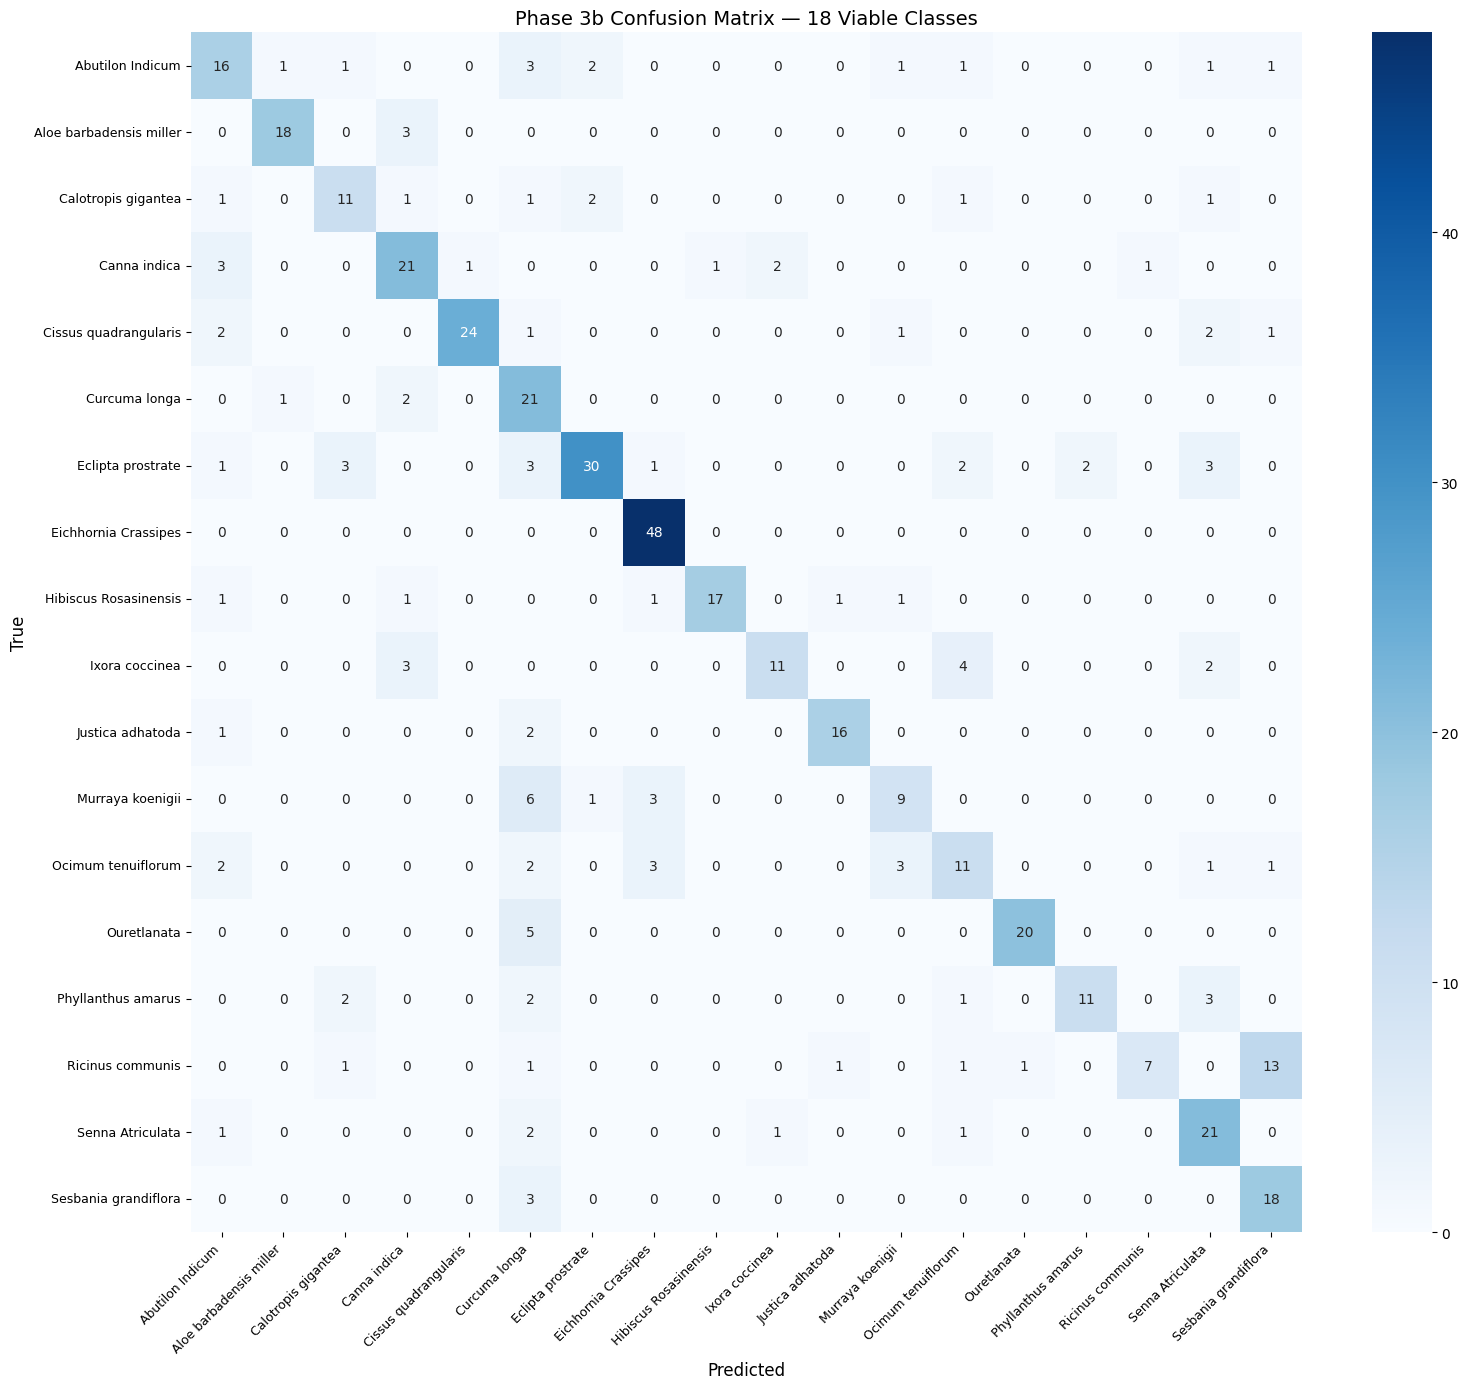

Confusion matrix saved to /content/drive/MyDrive/MedicinalPlant_Dissertation/18class_eval_results/


In [8]:
# 18-class confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all, labels=range(NUM_CLASSES_18))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_18, yticklabels=class_names_18, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Phase 3b Confusion Matrix — 18 Viable Classes', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'phase3b_18class_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion matrix saved to {RESULTS_DIR}/")

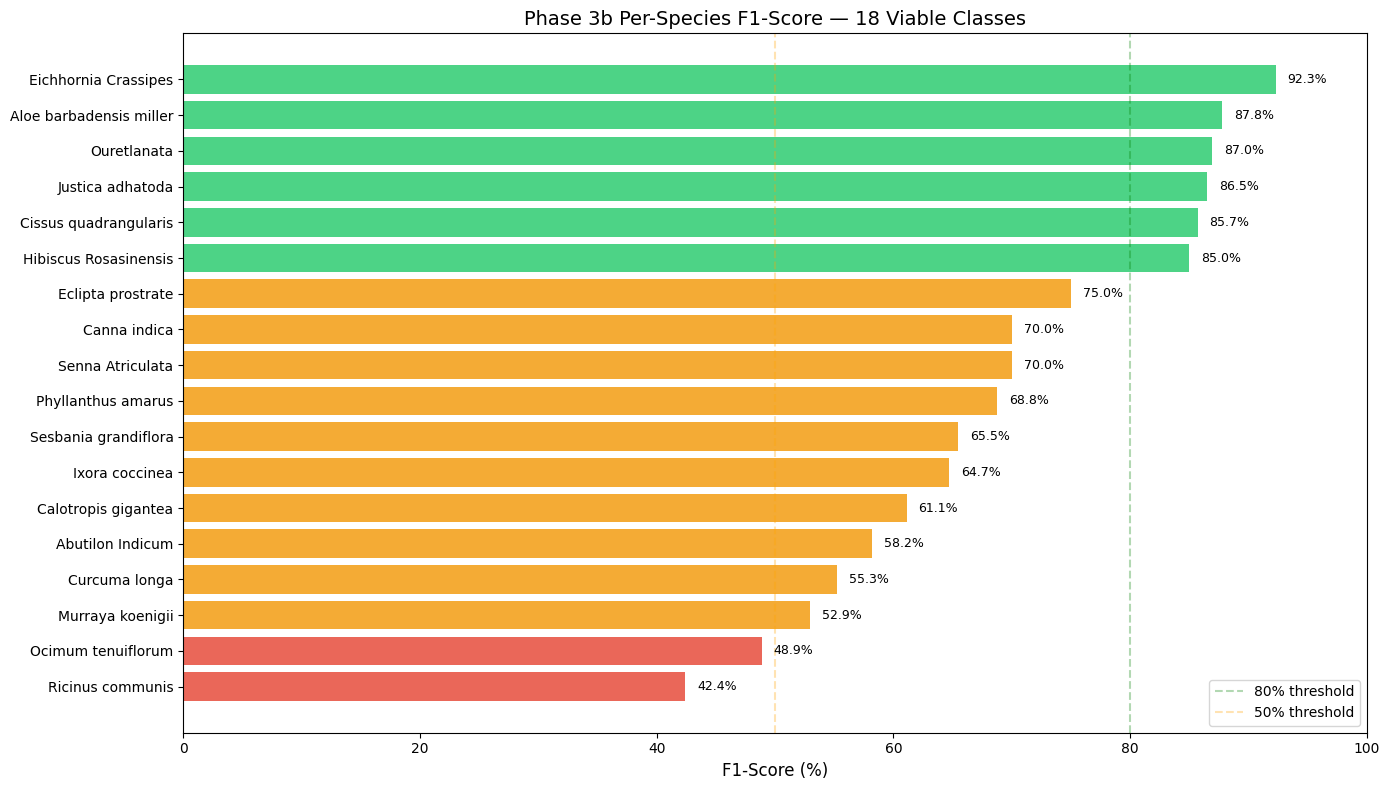

In [9]:
# Per-species F1 bar chart
species_f1 = {name: report_dict[name]['f1-score'] for name in class_names_18}
sorted_species = sorted(species_f1.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(14, 8))
names = [s[0] for s in sorted_species]
f1s = [s[1]*100 for s in sorted_species]
colors = ['#2ecc71' if f >= 80 else '#f39c12' if f >= 50 else '#e74c3c' for f in f1s]
bars = ax.barh(range(len(names)), f1s, color=colors, alpha=0.85)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('F1-Score (%)', fontsize=12)
ax.set_title('Phase 3b Per-Species F1-Score — 18 Viable Classes', fontsize=14)
ax.set_xlim(0, 100)
ax.invert_yaxis()
for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{f1:.1f}%', va='center', fontsize=9)
ax.axvline(x=80, color='green', linestyle='--', alpha=0.3, label='80% threshold')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.3, label='50% threshold')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'phase3b_18class_f1_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Save all results to JSON
results = {
    'accuracy_18class': float(accuracy_18),
    'total_samples': int(len(y_true_all)),
    'correct': int(np.sum(y_true_all == y_pred_all)),
    'num_classes': NUM_CLASSES_18,
    'weighted_precision': float(report_dict['weighted avg']['precision']),
    'weighted_recall': float(report_dict['weighted avg']['recall']),
    'weighted_f1': float(report_dict['weighted avg']['f1-score']),
    'macro_precision': float(report_dict['macro avg']['precision']),
    'macro_recall': float(report_dict['macro avg']['recall']),
    'macro_f1': float(report_dict['macro avg']['f1-score']),
    'per_species': {
        name: {
            'precision': float(report_dict[name]['precision']),
            'recall': float(report_dict[name]['recall']),
            'f1': float(report_dict[name]['f1-score']),
            'support': int(report_dict[name]['support'])
        }
        for name in class_names_18
    },
    'ablation_comparison': {
        'direct_18class': 0.7446,
        'sequential_18class': float(accuracy_18),
        'gap_pp': round(74.46 - accuracy_18*100, 2)
    }
}

results_path = os.path.join(RESULTS_DIR, 'phase3b_18class_metrics.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"All results saved to: {results_path}")
print(f"\n>>> DONE — Use these numbers in the dissertation for fair ablation comparison <<<")

All results saved to: /content/drive/MyDrive/MedicinalPlant_Dissertation/18class_eval_results/phase3b_18class_metrics.json

>>> DONE — Use these numbers in the dissertation for fair ablation comparison <<<
